In [14]:
from __future__ import annotations

import sys
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import pandas as pd
import torch
from IPython.display import display

ROOT = Path.cwd().resolve()
if ROOT.name == 'research':
    ROOT = ROOT.parent

RESEARCH_ROOT = ROOT / 'research'
MT_ROOT = ROOT / 'mt-py-tools'
sys.path.insert(0, str(MT_ROOT / 'src'))

from mtlib.nn import (
    GridConfig,
    ResUNetAttention,
    RouteExtractionConfig,
    TrackInpaintDataset,
    load_checkpoint,
    load_frags,
    load_track_index,
    make_route_comparison_figure,
    make_route_extraction_grid_figure,
    predict_and_extract_route,
    predict_dataset_routes,
    read_track_fragment,
    save_route_comparison_png,
)

plt.style.use('default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = False

In [15]:
DATASET_PATH = MT_ROOT / 'mt_sorted.h5'
ARTIFACT_DIR = MT_ROOT / 'runs' / 'artifacts'
CHECKPOINT_PATH = MT_ROOT / 'runs' / 'mt-v2' / 'checkpoints' / 'best.pt'
OUT_DIR = RESEARCH_ROOT / 'output' / '28-track-restore-mtlib'
OUT_DIR.mkdir(parents=True, exist_ok=True)

for path in [DATASET_PATH, ARTIFACT_DIR, CHECKPOINT_PATH]:
    assert path.exists(), f'Missing path: {path}'

print(f'DATASET_PATH   : {DATASET_PATH}')
print(f'ARTIFACT_DIR   : {ARTIFACT_DIR}')
print(f'CHECKPOINT_PATH: {CHECKPOINT_PATH}')
print(f'OUT_DIR        : {OUT_DIR}')

DATASET_PATH   : /Volumes/SSD/mark/Documents/Projects/marinetraffic-collector/mt-py-tools/mt_sorted.h5
ARTIFACT_DIR   : /Volumes/SSD/mark/Documents/Projects/marinetraffic-collector/mt-py-tools/runs/artifacts
CHECKPOINT_PATH: /Volumes/SSD/mark/Documents/Projects/marinetraffic-collector/mt-py-tools/runs/mt-v2/checkpoints/best.pt
OUT_DIR        : /Volumes/SSD/mark/Documents/Projects/marinetraffic-collector/research/output/28-track-restore-mtlib


In [16]:
grid_cfg = GridConfig()
extract_cfg = RouteExtractionConfig()
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

frags_train = load_frags(ARTIFACT_DIR / 'frags_train.parquet')
frags_val = load_frags(ARTIFACT_DIR / 'frags_val.parquet')
track_index = load_track_index(ARTIFACT_DIR / 'track_index.pkl')

train_ds = TrackInpaintDataset(
    dataset_path=DATASET_PATH,
    frags_path=ARTIFACT_DIR / 'frags_train.parquet',
    track_index_path=ARTIFACT_DIR / 'track_index.pkl',
    density_path=ARTIFACT_DIR / 'density.npz',
    grid_cfg=grid_cfg,
    seed=123,
    return_meta=True,
)

val_ds = TrackInpaintDataset(
    dataset_path=DATASET_PATH,
    frags_path=ARTIFACT_DIR / 'frags_val.parquet',
    track_index_path=ARTIFACT_DIR / 'track_index.pkl',
    density_path=ARTIFACT_DIR / 'density.npz',
    grid_cfg=grid_cfg,
    seed=123,
    return_meta=True,
)

model = ResUNetAttention(in_ch=4, out_ch=1, base_ch=32, groups=8, attn_heads=4).to(device)
load_checkpoint(CHECKPOINT_PATH, model=model, map_location=device)
model.eval()

print('device       :', device)
print('train frags  :', len(frags_train))
print('val frags    :', len(frags_val))
print('track index  :', len(track_index))
print('train_ds len :', len(train_ds))
print('val_ds len   :', len(val_ds))

device       : mps
train frags  : 426
val frags    : 10
track index  : 1391
train_ds len : 426
val_ds len   : 10


In [17]:
DEMO_SPLIT = 'val'
DEMO_INDEX = 0
demo_ds = val_ds if DEMO_SPLIT == 'val' else train_ds
demo_example = demo_ds[DEMO_INDEX]
demo_meta = demo_example['meta']

h5 = h5py.File(DATASET_PATH, 'r')
demo_fragment = read_track_fragment(
    h5,
    demo_ds.track_index,
    demo_meta['track_id'],
    demo_meta['s'],
    demo_meta['e'],
)

display(pd.DataFrame([demo_meta]))
print('fragment points:', len(demo_fragment))
print('gap           :', demo_meta['gaps'][0])

,idx,track_id,s,e,points,t0,t1,extent,gaps
0,0,30471,5,70,65,1730215470,1730256452,"[127.86747622012064, 128.87231564999655, 34.41...","[(5, 60)]"


fragment points: 65
gap           : (5, 60)


In [18]:
demo_prob_map, demo_result = predict_and_extract_route(
    model,
    demo_example,
    demo_fragment,
    grid_cfg=grid_cfg,
    device=device,
    extract_config=extract_cfg,
)

known = demo_example['x'].numpy()[0]

print('path source      :', demo_result.path_source)
print('path length      :', len(demo_result.path_cells))
print('mean prob on path:', demo_result.mean_prob_on_path)
print('start cell       :', demo_result.artifacts.start_cell)
print('end cell         :', demo_result.artifacts.end_cell)
print('graph nodes      :', demo_result.artifacts.graph.number_of_nodes())
print('graph edges      :', demo_result.artifacts.graph.number_of_edges())

path source      : skeleton graph
path length      : 145
mean prob on path: 0.7709848284721375
start cell       : (20, 12)
end cell         : (115, 92)
graph nodes      : 211
graph edges      : 268


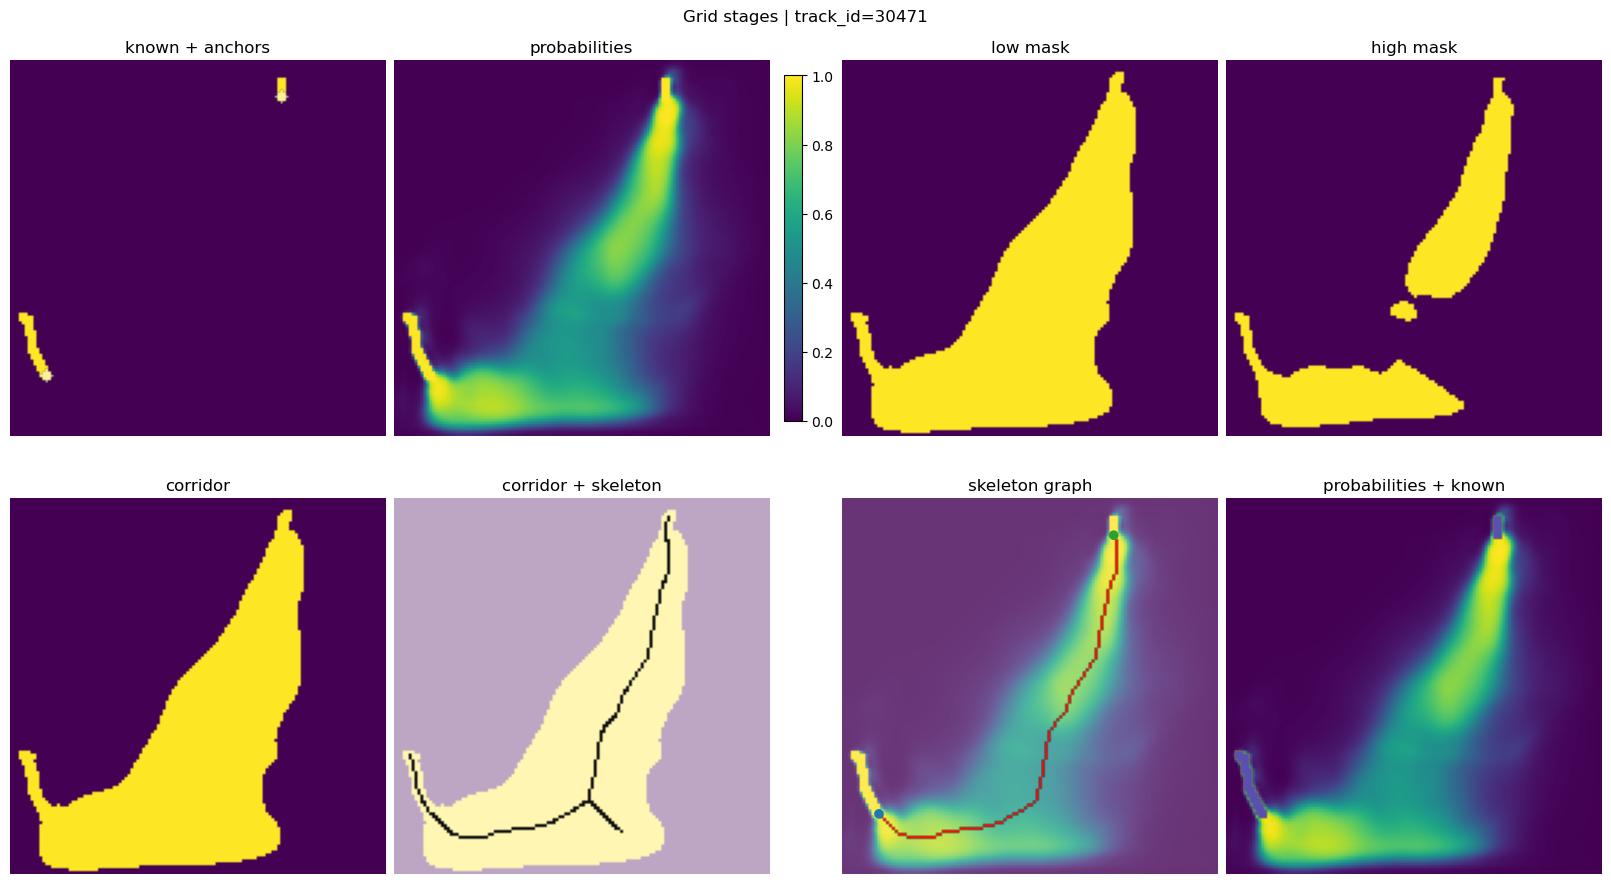

In [19]:
fig_grid = make_route_extraction_grid_figure(
    demo_prob_map,
    known,
    demo_result,
    title=f"Grid stages | track_id={demo_meta['track_id']}",
)
plt.show()

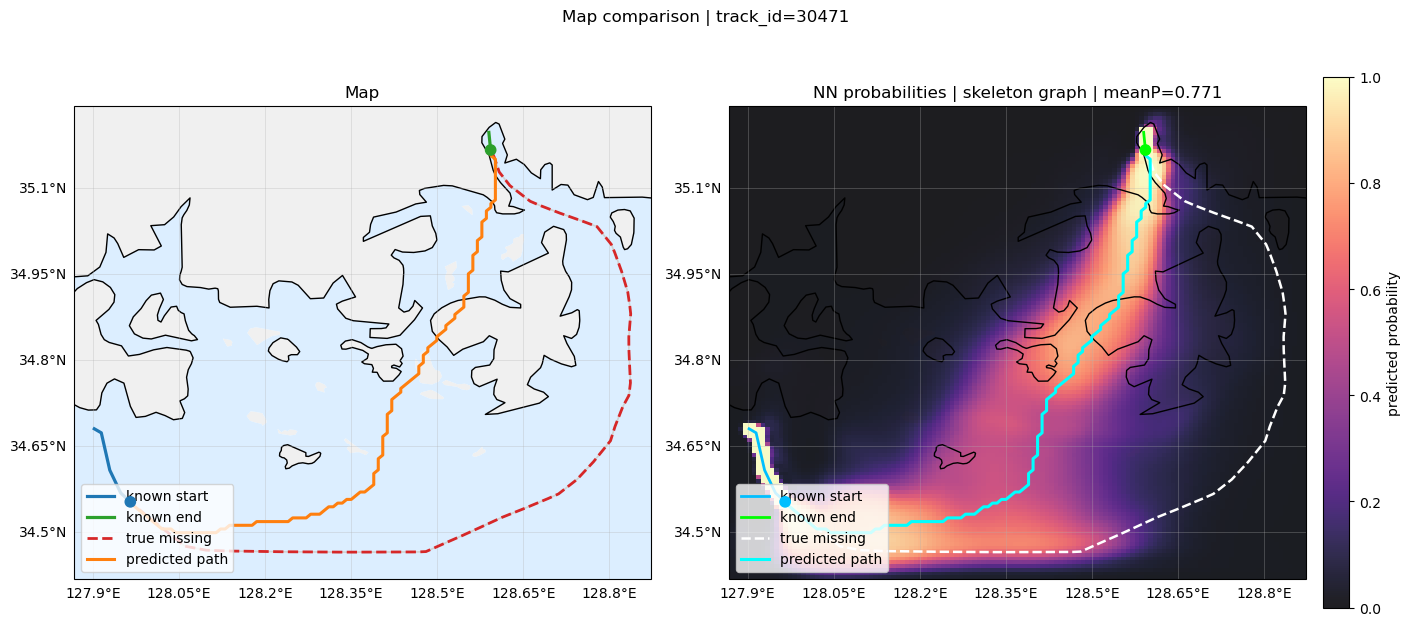

In [20]:
demo_gap = tuple(demo_meta['gaps'][0])
demo_extent = demo_meta['extent']

fig_map = make_route_comparison_figure(
    demo_fragment,
    demo_gap,
    demo_extent,
    demo_prob_map,
    demo_result,
    title=f"Map comparison | track_id={demo_meta['track_id']}",
)
plt.show()

In [21]:
single_png = OUT_DIR / f"demo_track_{demo_meta['track_id']}.png"
save_route_comparison_png(
    single_png,
    demo_fragment,
    demo_gap,
    demo_extent,
    demo_prob_map,
    demo_result,
    title=f"mtlib demo | track_id={demo_meta['track_id']}",
)
print(single_png)

/Volumes/SSD/mark/Documents/Projects/marinetraffic-collector/research/output/28-track-restore-mtlib/demo_track_30471.png


In [22]:
BATCH_INDICES = [0, 1, 2, 3, 4] if len(val_ds) >= 5 else list(range(len(val_ds)))
batch_df = predict_dataset_routes(
    model,
    val_ds,
    grid_cfg=grid_cfg,
    device=device,
    indices=BATCH_INDICES,
    extract_config=extract_cfg,
    progress=True,
)

display(batch_df[['idx', 'track_id', 's', 'e', 'path_source', 'path_len', 'mean_prob_on_path', 'graph_nodes', 'graph_edges']])

Predict dataset routes: 100%|██████████| 5/5 [00:00<00:00, 17.52it/s]


,idx,track_id,s,e,path_source,path_len,mean_prob_on_path,graph_nodes,graph_edges
0,0,30471,5,70,skeleton graph,145,0.770985,211,268
1,1,41909,0,32,skeleton graph,103,0.914745,169,233
2,2,54662,0,54,skeleton graph,116,0.795509,167,223
3,3,54662,54,94,skeleton graph,24,0.911013,150,164
4,4,65499,1,52,skeleton graph,51,0.993358,221,277


In [23]:
saved_paths = []
for _, row in batch_df.iterrows():
    result = row['result']
    meta = row['meta']
    fragment = read_track_fragment(
        h5,
        val_ds.track_index,
        meta['track_id'],
        meta['s'],
        meta['e'],
    )
    out_path = OUT_DIR / f"batch_{int(row['idx']):03d}_track_{int(row['track_id'])}.png"
    save_route_comparison_png(
        out_path,
        fragment,
        tuple(meta['gaps'][0]),
        meta['extent'],
        row['prob_map'],
        result,
        title=f"batch idx={int(row['idx'])} | track_id={int(row['track_id'])}",
    )
    saved_paths.append(out_path)

print('saved batch figures:', len(saved_paths))
display(pd.DataFrame({'path': [str(p) for p in saved_paths]}))

saved batch figures: 5


,path
0,/Volumes/SSD/mark/Documents/Projects/marinetra...
1,/Volumes/SSD/mark/Documents/Projects/marinetra...
2,/Volumes/SSD/mark/Documents/Projects/marinetra...
3,/Volumes/SSD/mark/Documents/Projects/marinetra...
4,/Volumes/SSD/mark/Documents/Projects/marinetra...


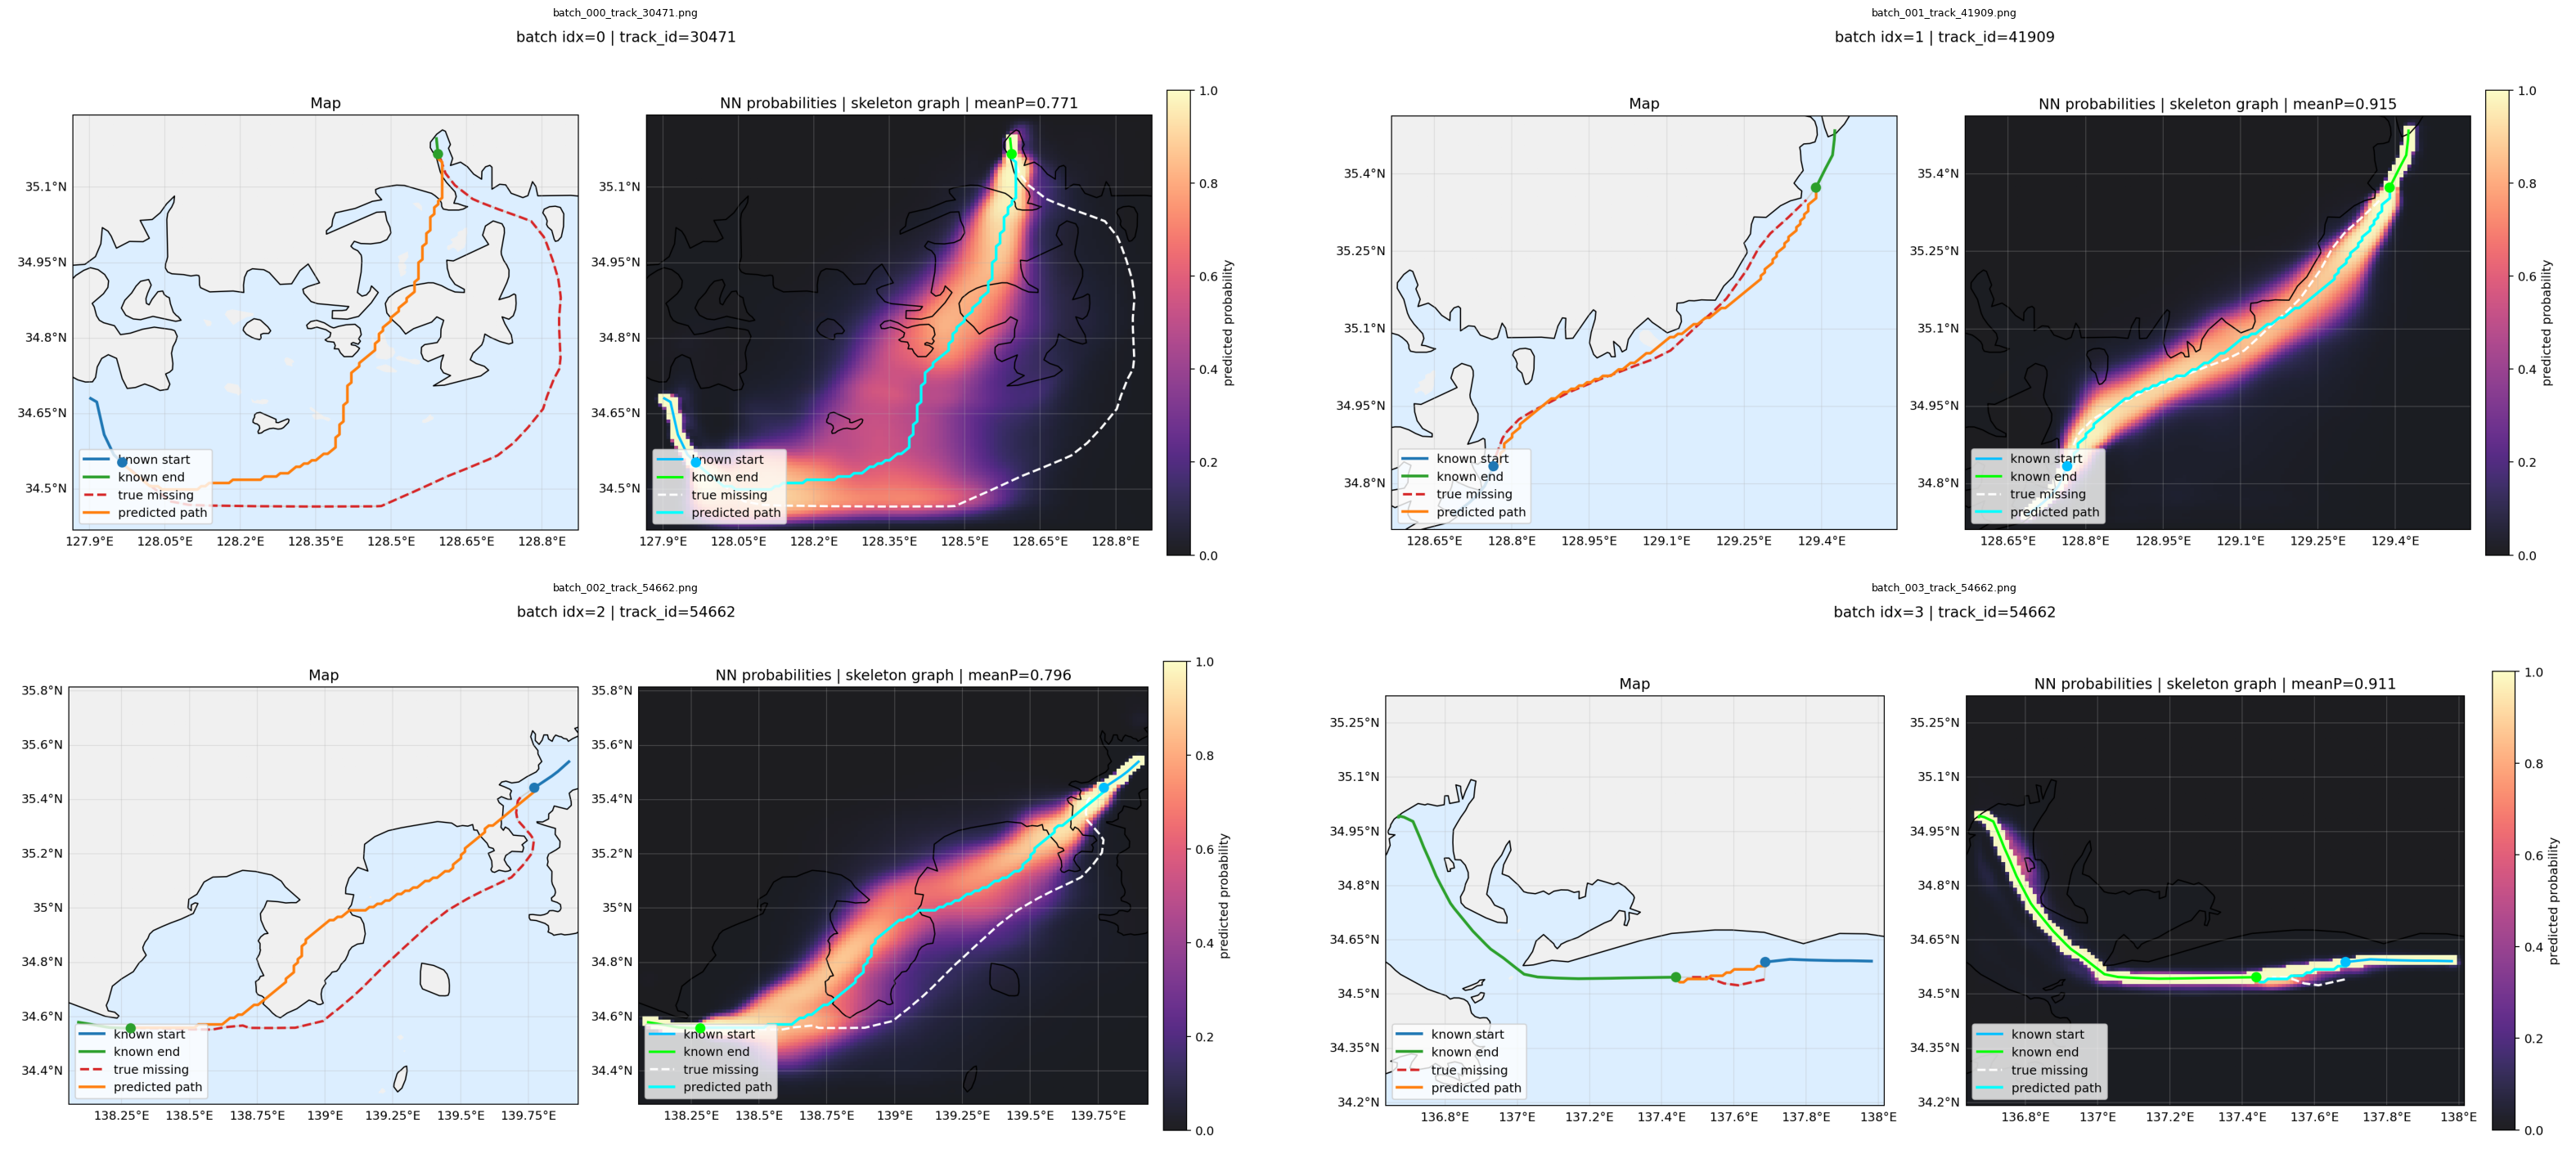

In [24]:
preview_paths = saved_paths[:4]
fig, axs = plt.subplots(2, 2, figsize=(32, 14), constrained_layout=True)
for ax, img_path in zip(axs.flat, preview_paths, strict=False):
    img = plt.imread(img_path)
    ax.imshow(img)
    ax.set_title(Path(img_path).name, fontsize=9)
    ax.axis('off')
for ax in axs.flat[len(preview_paths):]:
    ax.axis('off')
plt.show()